# Module 2 — Analytics Pipeline
## Part A: EDA — `01_eda.ipynb`

**Dataset**: Titanic — loaded once via `sns.load_dataset('titanic')`, immediately saved as `titanic.csv` offline fallback.

**Pipeline order**: Load → Profile → Clean → Univariate → Bivariate → Multivariate → EDA Standardization → Save CSV

> **How to run**: `Kernel → Restart Kernel and Run All Cells`

---

In [2]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn

print(f'pandas   version : {pd.__version__}')
print(f'seaborn  version : {sns.__version__}')
print(f'sklearn  version : {sklearn.__version__}')
print(f'numpy    version : {np.__version__}')

pandas   version : 2.2.2
seaborn  version : 0.13.2
sklearn  version : 1.9.1
numpy    version : 2.4.6


## Step 1 — Load Dataset, Profile, Report Missing Values, Save Offline Fallback

In [3]:
# -- Load ONCE from seaborn (network/cache on first run, local cache after) ----
# This is the ONE AND ONLY sns.load_dataset call in this entire module.
# 02_modeling.ipynb reads titanic.csv — it never calls sns.load_dataset again.

df = sns.load_dataset('titanic')

# -- IMMEDIATELY save as offline fallback — this file is committed to the repo -
df.to_csv('titanic.csv', index=False)

print('Dataset loaded and saved to titanic.csv')
print(f'Shape: {df.shape}')   # expected (891, 15)

Dataset loaded and saved to titanic.csv
Shape: (891, 15)


In [4]:
# -- df.info() -----------------------------------------------------------------
print('-- df.info() --')
df.info()


-- df.info() --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
# -- df.describe() ---------------
# ----------------------------------------------
print('-- df.describe() --')
display(df.describe())

-- df.describe() --


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# -- Missing value profile ------------------------------------------------------
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct':   missing_pct
})
missing_report = missing_report[missing_report['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print('-- Columns with missing values --')
print(missing_report.to_string())
print()

# -- Threshold rule applied to each column -------------------------------------
print('-- Threshold rule decisions --')
print('Column        | Missing %  | Rule              | Decision')
print('-' * 70)
for col, row in missing_report.iterrows():
    pct = row['missing_pct']
    if pct < 5:
        rule     = '< 5%  -> drop rows'
        decision = 'Drop those rows'
    elif pct <= 30:
        rule     = '5-30% -> impute'
        decision = 'Median imputation'
    else:
        rule     = '> 30% -> drop column'
        decision = 'Drop column'
    print(f'{col:<14}| {pct:>9.2f}% | {rule:<18} | {decision}')

-- Columns with missing values --
             missing_count  missing_pct
deck                   688        77.22
age                    177        19.87
embarked                 2         0.22
embark_town              2         0.22

-- Threshold rule decisions --
Column        | Missing %  | Rule              | Decision
----------------------------------------------------------------------
deck          |     77.22% | > 30% -> drop column | Drop column
age           |     19.87% | 5-30% -> impute    | Median imputation
embarked      |      0.22% | < 5%  -> drop rows | Drop those rows
embark_town   |      0.22% | < 5%  -> drop rows | Drop those rows


In [7]:
# -- Assertions: confirm shape and expected columns -----------------------------
assert df.shape == (891, 15), f'Unexpected shape: {df.shape}'
assert 'survived' in df.columns
assert 'age'      in df.columns
assert 'fare'     in df.columns

import os
assert os.path.exists('titanic.csv'), 'titanic.csv was not saved!'

print(f'✅ STEP 1 COMPLETE')
print(f'   Shape           : {df.shape}')
print(f'   titanic.csv     : saved ({os.path.getsize("titanic.csv")} bytes)')
print(f'   Columns w/ NaN  : {len(missing_report)}')

✅ STEP 1 COMPLETE
   Shape           : (891, 15)
   titanic.csv     : saved (57910 bytes)
   Columns w/ NaN  : 4


---
## Step 2 — Apply Missing Value Handling

Applying the threshold rules identified in Step 1:

| Column | Missing % | Rule | Strategy |
|--------|-----------|------|----------|
| `deck` | 77.22% | > 30% unreliable | **Drop column** |
| `age` | 19.87% | 5-30% impute | **Median imputation** |
| `embarked` | 0.22% | < 5% drop rows | **Drop those rows** |
| `embark_town` | 0.22% | < 5% drop rows | **Drop those rows** |

**Justifications**:
- `deck`: 77% missing — imputing would fabricate data for 3 out of 4 rows; dropping is the only defensible choice.
- `age`: 19.87% falls squarely in the 5-30% range. Median imputation is robust to the right-skew typical of age distributions and preserves all rows.
- `embarked` / `embark_town`: Only 2 rows affected. Dropping has negligible impact on the 889-row dataset.

In [8]:
# -- 2a. Drop rows where embarked / embark_town is missing (< 5% rule) ---------
rows_before = len(df)
df = df.dropna(subset=['embarked', 'embark_town'])
print(f'Rows dropped (embarked/embark_town NaN) : {rows_before - len(df)}')
print(f'Rows remaining                          : {len(df)}')

Rows dropped (embarked/embark_town NaN) : 2
Rows remaining                          : 889


In [9]:
# -- 2b. Impute age with median (5-30% rule) ------------------------------------
age_nan_before = df['age'].isna().sum()
age_median     = df['age'].median()
df['age']      = df['age'].fillna(age_median)
age_nan_after  = df['age'].isna().sum()

print(f'age NaN before imputation : {age_nan_before}')
print(f'age median used           : {age_median}')
print(f'age NaN after imputation  : {age_nan_after}')

age NaN before imputation : 177
age median used           : 28.0
age NaN after imputation  : 0


In [10]:
# -- 2c. Drop deck column (> 30% rule) -----------------------------------------
df = df.drop(columns=['deck'])
print(f'deck column dropped.')
print(f'Shape after all cleaning : {df.shape}')

deck column dropped.
Shape after all cleaning : (889, 14)


In [11]:
# -- 2d. Verify — no remaining NaNs in columns we use downstream ---------------
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

print('Remaining NaN columns after cleaning:')
if len(remaining_nulls) == 0:
    print('  None — all handled.')
else:
    print(remaining_nulls.to_string())

# Key columns used downstream must have zero NaNs
for col in ['age', 'fare', 'survived', 'pclass', 'sex', 'embarked']:
    assert df[col].isna().sum() == 0, f'NaN found in {col}'

assert 'deck' not in df.columns, 'deck column should have been dropped'

print(f'\n✅ STEP 2 COMPLETE')
print(f'   Final shape             : {df.shape}')
print(f'   age NaN after impute    : {df["age"].isna().sum()}')
print(f'   deck column present     : {"deck" in df.columns}')

Remaining NaN columns after cleaning:
  None — all handled.

✅ STEP 2 COMPLETE
   Final shape             : (889, 14)
   age NaN after impute    : 0
   deck column present     : False


---
## Step 3 — Univariate Analysis: Histograms, Box Plots, IQR Outliers, Fare Skewness

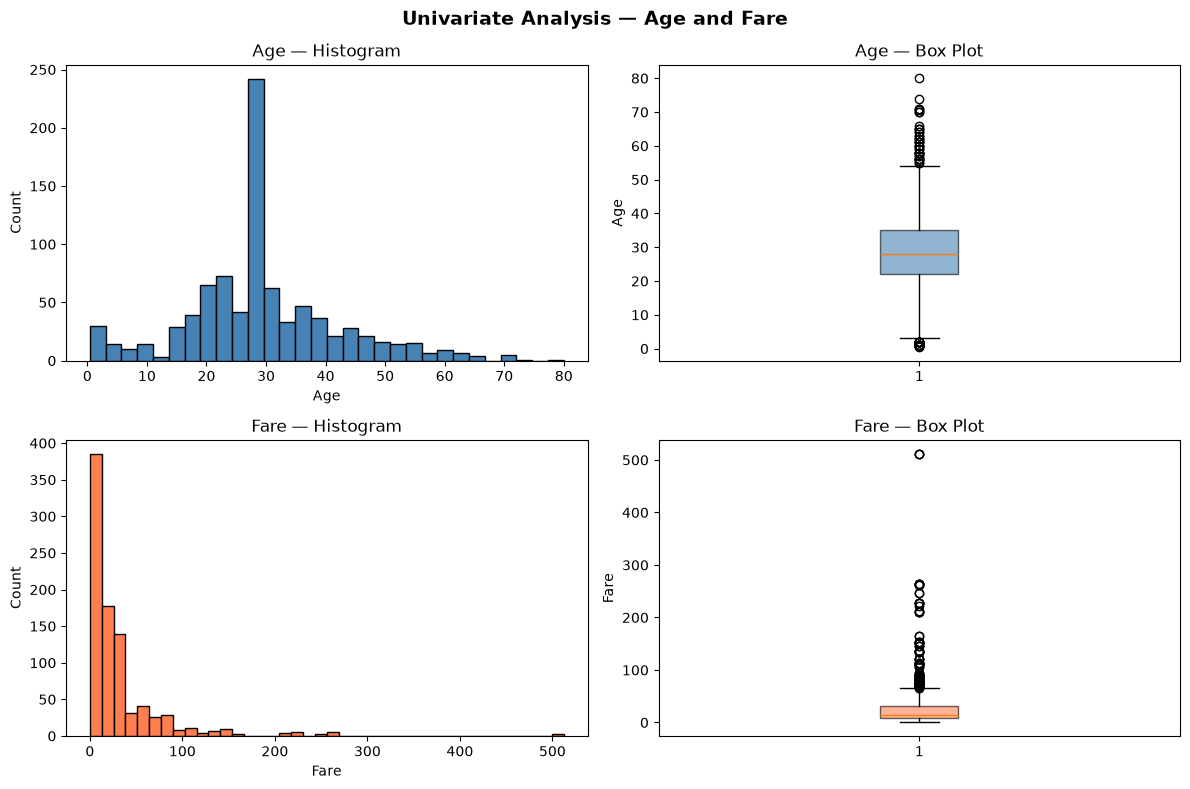

Saved: univariate_plots.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# -- Histogram — age -----------------------------------------------------------
axes[0, 0].hist(df['age'].dropna(), bins=30, edgecolor='black', color='steelblue')
axes[0, 0].set_title('Age — Histogram')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

# -- Box plot — age ------------------------------------------------------------
axes[0, 1].boxplot(df['age'].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0, 1].set_title('Age — Box Plot')
axes[0, 1].set_ylabel('Age')

# -- Histogram — fare ----------------------------------------------------------
axes[1, 0].hist(df['fare'], bins=40, edgecolor='black', color='coral')
axes[1, 0].set_title('Fare — Histogram')
axes[1, 0].set_xlabel('Fare')
axes[1, 0].set_ylabel('Count')

# -- Box plot — fare -----------------------------------------------------------
axes[1, 1].boxplot(df['fare'], patch_artist=True,
                   boxprops=dict(facecolor='coral', alpha=0.6))
axes[1, 1].set_title('Fare — Box Plot')
axes[1, 1].set_ylabel('Fare')

plt.suptitle('Univariate Analysis — Age and Fare', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('univariate_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: univariate_plots.png')

In [13]:
# -- IQR outlier counts --------------------------------------------------------
def iqr_outlier_report(series, label):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    n_out  = int(((series < lower) | (series > upper)).sum())
    print(f'{label}')
    print(f'  Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}')
    print(f'  Lower bound : {lower:.2f}')
    print(f'  Upper bound : {upper:.2f}')
    print(f'  Outliers    : {n_out}')
    return n_out, lower, upper

print('=' * 50)
age_outliers,  age_lo,  age_hi  = iqr_outlier_report(df['age'],  'age')
print()
fare_outliers, fare_lo, fare_hi = iqr_outlier_report(df['fare'], 'fare')
print('=' * 50)

age
  Q1=22.00  Q3=35.00  IQR=13.00
  Lower bound : 2.50
  Upper bound : 54.50
  Outliers    : 65

fare
  Q1=7.90  Q3=31.00  IQR=23.10
  Lower bound : -26.76
  Upper bound : 65.66
  Outliers    : 114


In [14]:
# -- Fare: mean / median / mode — skewness conclusion -------------------------
fare_mean   = df['fare'].mean()
fare_median = df['fare'].median()
fare_mode   = df['fare'].mode()[0]

print('Fare — Descriptive Statistics')
print(f'  Mean   : {fare_mean:.4f}')
print(f'  Median : {fare_median:.4f}')
print(f'  Mode   : {fare_mode:.4f}')
print()

if fare_mean > fare_median > fare_mode:
    skew_direction = 'RIGHT-SKEWED (mean > median > mode)'
elif fare_mean < fare_median < fare_mode:
    skew_direction = 'LEFT-SKEWED  (mean < median < mode)'
else:
    skew_direction = 'APPROXIMATELY SYMMETRIC'

print(f'Skewness conclusion: fare is {skew_direction}')
print()
print('Interpretation: Most passengers paid low fares; a small number of')
print('1st-class passengers paid very high fares, pulling the mean rightward.')
print('The long right tail is visible in both the histogram and box plot above.')

# Assertion — spec requires right-skewed conclusion
assert fare_mean > fare_median, 'Expected mean > median for right-skewed fare'

print(f'\n✅ STEP 3 COMPLETE')
print(f'   age  outliers : {age_outliers}')
print(f'   fare outliers : {fare_outliers}')
print(f'   fare skewness : {skew_direction}')

Fare — Descriptive Statistics
  Mean   : 32.0967
  Median : 14.4542
  Mode   : 8.0500

Skewness conclusion: fare is RIGHT-SKEWED (mean > median > mode)

Interpretation: Most passengers paid low fares; a small number of
1st-class passengers paid very high fares, pulling the mean rightward.
The long right tail is visible in both the histogram and box plot above.

✅ STEP 3 COMPLETE
   age  outliers : 65
   fare outliers : 114
   fare skewness : RIGHT-SKEWED (mean > median > mode)


---
## Step 4 — Bivariate Analysis: Survival Rates + Correlation Matrix

Survival rates broken down by **(a) sex**, **(b) pclass**, **(c) sex x pclass**.

Correlation matrix computed on **exactly 6 columns**: `survived, pclass, age, sibsp, parch, fare`.
`adult_male` and `alone` are excluded — they are derived/redundant flags (directly computable from other columns), not independent measured features.

In [15]:
# -- (a) Survival rate by sex ---------------------------------------------------
sex_survival = df.groupby('sex')['survived'].mean().round(4)
print('(a) Survival rate by sex:')
print(sex_survival.to_string())
print()

# -- (b) Survival rate by pclass -----------------------------------------------
pclass_survival = df.groupby('pclass')['survived'].mean().round(4)
print('(b) Survival rate by pclass:')
print(pclass_survival.to_string())
print()

# -- (c) Survival rate by sex AND pclass (boolean masking) ---------------------
print('(c) Survival rate by sex AND pclass (boolean masking):')
print(f'  {"Sex":<8} {"Pclass":<8} {"Survival Rate"}')
print(f'  {"-"*30}')
for sex in ['female', 'male']:
    for pclass in [1, 2, 3]:
        mask = (df['sex'] == sex) & (df['pclass'] == pclass)
        rate = df.loc[mask, 'survived'].mean()
        print(f'  {sex:<8} {pclass:<8} {rate:.4f}')

(a) Survival rate by sex:
sex
female    0.7404
male      0.1889

(b) Survival rate by pclass:
pclass
1    0.6262
2    0.4728
3    0.2424

(c) Survival rate by sex AND pclass (boolean masking):
  Sex      Pclass   Survival Rate
  ------------------------------
  female   1        0.9674
  female   2        0.9211
  female   3        0.5000
  male     1        0.3689
  male     2        0.1574
  male     3        0.1354


In [16]:
# -- Correlation matrix — EXACTLY these 6 columns -----------------------------
# adult_male and alone are EXCLUDED (derived/redundant flags)
corr_cols   = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = df[corr_cols].corr()

print('6x6 Correlation Matrix:')
print(corr_matrix.round(4).to_string())
print()

6x6 Correlation Matrix:
          survived  pclass     age   sibsp   parch    fare
survived    1.0000 -0.3355 -0.0698 -0.0340  0.0832  0.2553
pclass     -0.3355  1.0000 -0.3365  0.0817  0.0168 -0.5482
age        -0.0698 -0.3365  1.0000 -0.2325 -0.1715  0.0937
sibsp      -0.0340  0.0817 -0.2325  1.0000  0.4145  0.1609
parch       0.0832  0.0168 -0.1715  0.4145  1.0000  0.2175
fare        0.2553 -0.5482  0.0937  0.1609  0.2175  1.0000



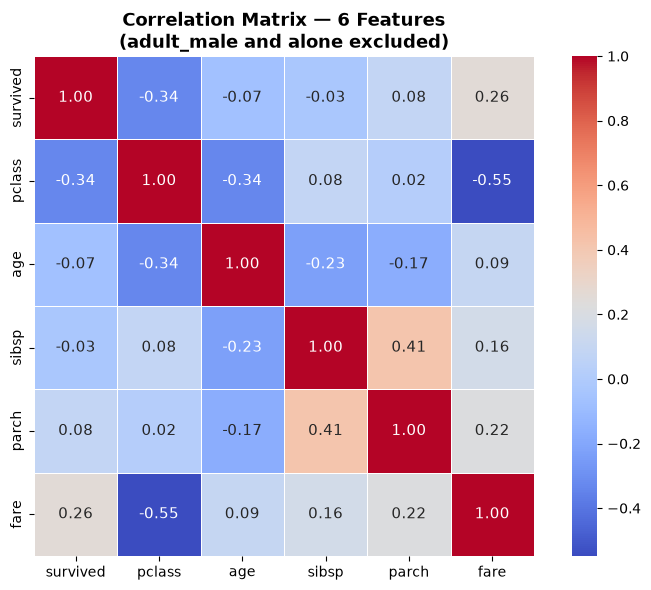

Saved: correlation_heatmap.png


In [17]:
# -- Correlation heatmap -------------------------------------------------------
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, annot_kws={'size': 11})
plt.title('Correlation Matrix — 6 Features\n(adult_male and alone excluded)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')

In [18]:
# -- Find top 2 off-diagonal correlations by absolute value --------------------
import numpy as np

corr_abs = corr_matrix.abs()
mask_tri = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
pairs    = corr_abs.where(mask_tri).stack().sort_values(ascending=False)

print('Top off-diagonal correlations (by absolute value):')
print(f'  {"Rank":<6} {"Feature Pair":<25} {"Abs Correlation"}')
print(f'  {"-"*50}')
for rank, ((col_a, col_b), val) in enumerate(pairs.items(), 1):
    print(f'  {rank:<6} {col_a} <-> {col_b:<20} {val:.4f}')

top1_pair = pairs.index[0]
top2_pair = pairs.index[1]
print(f'\nTop 1: {top1_pair[0]} <-> {top1_pair[1]}  (|r| = {pairs.iloc[0]:.4f})')
print(f'Top 2: {top2_pair[0]} <-> {top2_pair[1]}  (|r| = {pairs.iloc[1]:.4f})')

print(f'\n\u2705 STEP 4 COMPLETE')
print(f'   Correlation matrix shape : {corr_matrix.shape}')
print(f'   Columns used             : {corr_cols}')
print(f'   Top 2 pairs              : {top1_pair}, {top2_pair}')

Top off-diagonal correlations (by absolute value):
  Rank   Feature Pair              Abs Correlation
  --------------------------------------------------
  1      pclass <-> fare                 0.5482
  2      sibsp <-> parch                0.4145
  3      pclass <-> age                  0.3365
  4      survived <-> pclass               0.3355
  5      survived <-> fare                 0.2553
  6      age <-> sibsp                0.2325
  7      parch <-> fare                 0.2175
  8      age <-> parch                0.1715
  9      sibsp <-> fare                 0.1609
  10     age <-> fare                 0.0937
  11     survived <-> parch                0.0832
  12     pclass <-> sibsp                0.0817
  13     survived <-> age                  0.0698
  14     survived <-> sibsp                0.0340
  15     pclass <-> parch                0.0168

Top 1: pclass <-> fare  (|r| = 0.5482)
Top 2: sibsp <-> parch  (|r| = 0.4145)

✅ STEP 4 COMPLETE
   Correlation matrix shape :

---
## Step 5 — Multivariate Data Story (4 Charts)

Each chart builds on the bivariate findings to tell a coherent story about **who was more likely to survive and why**.

| Chart | Question answered |
|-------|------------------|
| 1 — Survival count by sex | Did sex determine survival? |
| 2 — Survival rate by pclass and sex | How did class and sex interact? |
| 3 — Age distribution by survival | Did age play a role? |
| 4 — Fare distribution by pclass and survival | Does fare (proxy for wealth) link to survival? |

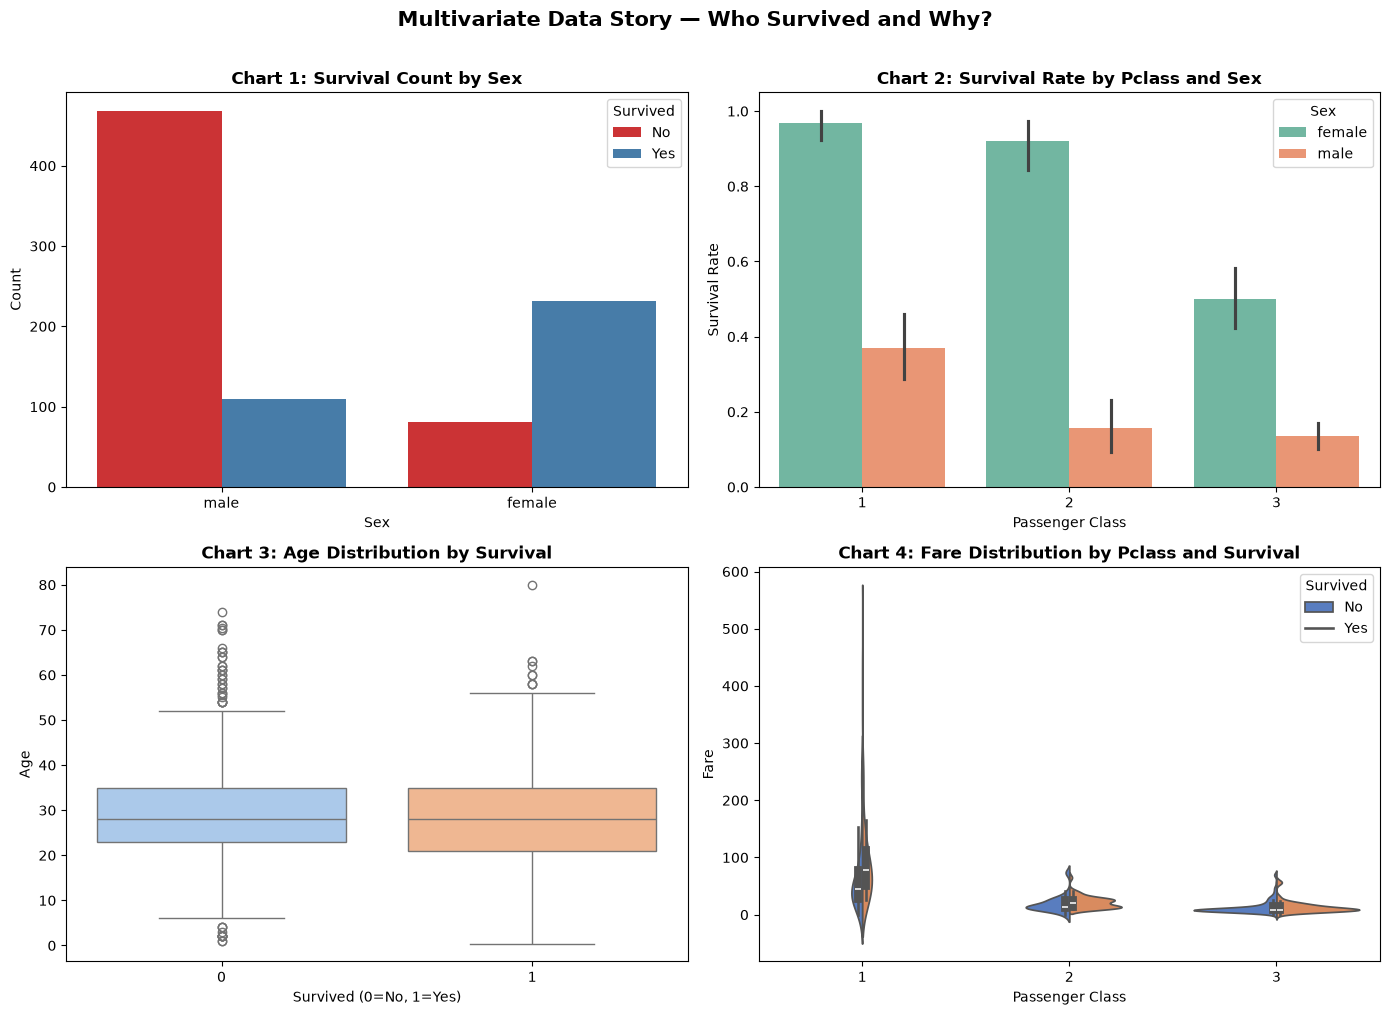

Saved: multivariate_story.png


In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -- Chart 1: Survival count by sex (countplot) --------------------------------
sns.countplot(data=df, x='sex', hue='survived', palette='Set1', ax=axes[0, 0])
axes[0, 0].set_title('Chart 1: Survival Count by Sex', fontweight='bold')
axes[0, 0].set_xlabel('Sex')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(title='Survived', labels=['No', 'Yes'])

# -- Chart 2: Survival rate by pclass and sex (grouped bar) --------------------
sns.barplot(data=df, x='pclass', y='survived', hue='sex', palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('Chart 2: Survival Rate by Pclass and Sex', fontweight='bold')
axes[0, 1].set_xlabel('Passenger Class')
axes[0, 1].set_ylabel('Survival Rate')
axes[0, 1].legend(title='Sex')

# -- Chart 3: Age distribution by survival (box plot) --------------------------
sns.boxplot(data=df, x='survived', y='age', hue='survived', palette='pastel', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Chart 3: Age Distribution by Survival', fontweight='bold')
axes[1, 0].set_xlabel('Survived (0=No, 1=Yes)')
axes[1, 0].set_ylabel('Age')

# -- Chart 4: Fare distribution by pclass (violin split by survival) -----------
sns.violinplot(data=df, x='pclass', y='fare', hue='survived',
               split=True, palette='muted', ax=axes[1, 1])
axes[1, 1].set_title('Chart 4: Fare Distribution by Pclass and Survival', fontweight='bold')
axes[1, 1].set_xlabel('Passenger Class')
axes[1, 1].set_ylabel('Fare')
axes[1, 1].legend(title='Survived', labels=['No', 'Yes'])

plt.suptitle('Multivariate Data Story — Who Survived and Why?',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('multivariate_story.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: multivariate_story.png')

In [20]:
print('=' * 70)
print('MULTIVARIATE CHART INTERPRETATIONS')
print('=' * 70)

print()
print('Chart 1 — Survival Count by Sex')
print('  Women survived at far higher rates than men (~74% vs ~19%).')
print('  The "women and children first" evacuation protocol is clearly')
print('  visible in the data — far more women survived than perished,')
print('  while the reverse is true for men.')

print()
print('Chart 2 — Survival Rate by Pclass and Sex')
print('  1st-class females had ~97% survival; 3rd-class males had ~13%.')
print('  Class and sex together are the two strongest survival predictors.')
print('  Even within the same sex, 1st-class passengers survived at')
print('  dramatically higher rates than 3rd-class passengers.')

print()
print('Chart 3 — Age Distribution by Survival')
print('  Survivors tend to be slightly younger on average, though overlap')
print('  is large. Children under ~10 show a notably higher survival rate.')
print('  The median age of survivors is lower than non-survivors, consistent')
print('  with the priority given to women and children during evacuation.')

print()
print('Chart 4 — Fare Distribution by Pclass and Survival')
print('  1st-class passengers paid far higher fares and survived at higher')
print('  rates — confirming the pclass <-> fare <-> survived relationship')
print('  seen in the correlation matrix. Higher fare (a proxy for wealth and')
print('  class) correlates strongly with survival across all three classes.')

print()
print('✅ STEP 5 COMPLETE — 4 multivariate charts saved to multivariate_story.png')

MULTIVARIATE CHART INTERPRETATIONS

Chart 1 — Survival Count by Sex
  Women survived at far higher rates than men (~74% vs ~19%).
  The "women and children first" evacuation protocol is clearly
  visible in the data — far more women survived than perished,
  while the reverse is true for men.

Chart 2 — Survival Rate by Pclass and Sex
  1st-class females had ~97% survival; 3rd-class males had ~13%.
  Class and sex together are the two strongest survival predictors.
  Even within the same sex, 1st-class passengers survived at
  dramatically higher rates than 3rd-class passengers.

Chart 3 — Age Distribution by Survival
  Survivors tend to be slightly younger on average, though overlap
  is large. Children under ~10 show a notably higher survival rate.
  The median age of survivors is lower than non-survivors, consistent
  with the priority given to women and children during evacuation.

Chart 4 — Fare Distribution by Pclass and Survival
  1st-class passengers paid far higher fares and s

---
## Step 6 — EDA Standardization Check (age and fare)

**Purpose**: EDA-only sanity check — confirms that z-score standardization produces mean ≈ 0 and std ≈ 1.

**Important**: This does NOT feed into the modeling pipeline.
`02_modeling.ipynb` runs its own `StandardScaler` fit **only on `X_train`** to prevent data leakage.

In [21]:
from sklearn.preprocessing import StandardScaler

# -- EDA-only: standardize on the full cleaned df (sanity check only) ----------
scaler_eda = StandardScaler()
df_scaled_check = df[['age', 'fare']].copy()
df_scaled_check[['age_z', 'fare_z']] = scaler_eda.fit_transform(df_scaled_check[['age', 'fare']])

print('-- Before standardization --')
before = df[['age', 'fare']].agg(['mean', 'std']).round(4)
print(before.to_string())

print()
print('-- After standardization --')
after = df_scaled_check[['age_z', 'fare_z']].agg(['mean', 'std']).round(4)
print(after.to_string())

-- Before standardization --
          age     fare
mean  29.3152  32.0967
std   12.9849  49.6975

-- After standardization --
       age_z  fare_z
mean  0.0000  0.0000
std   1.0006  1.0006


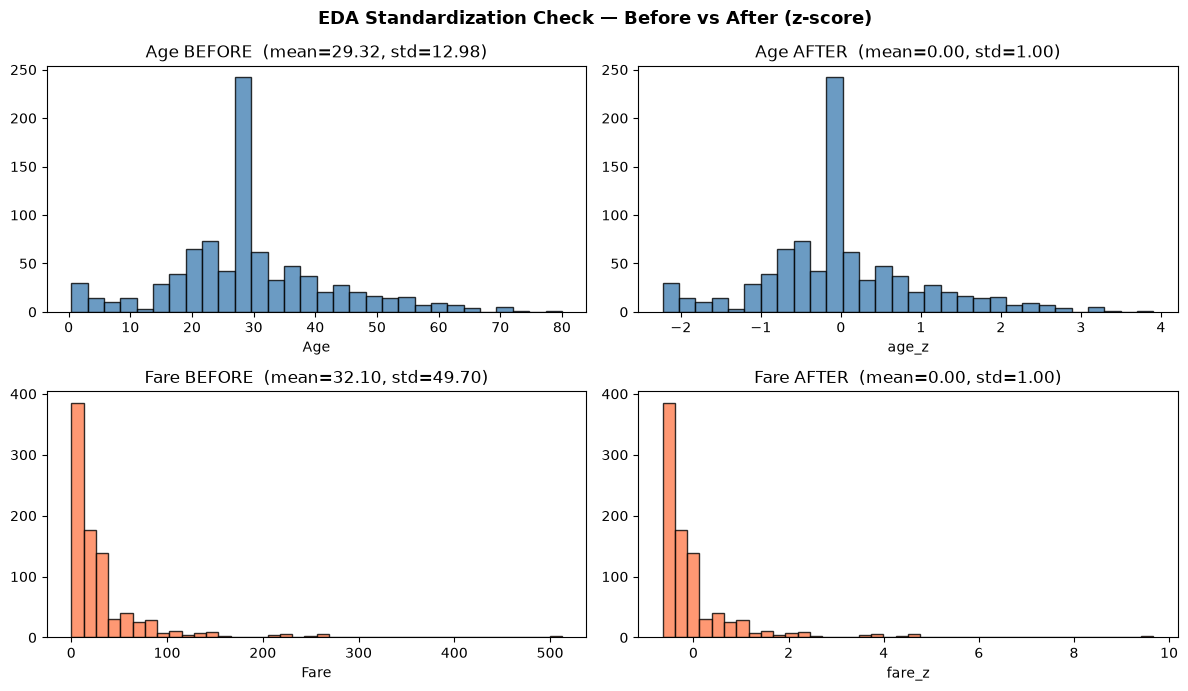

Saved: standardization_check.png


In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Before — age
axes[0, 0].hist(df['age'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 0].set_title(f'Age BEFORE  (mean={df["age"].mean():.2f}, std={df["age"].std():.2f})')
axes[0, 0].set_xlabel('Age')

# After — age_z
axes[0, 1].hist(df_scaled_check['age_z'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 1].set_title(f'Age AFTER  (mean={df_scaled_check["age_z"].mean():.2f}, std={df_scaled_check["age_z"].std():.2f})')
axes[0, 1].set_xlabel('age_z')

# Before — fare
axes[1, 0].hist(df['fare'], bins=40, color='coral', edgecolor='black', alpha=0.8)
axes[1, 0].set_title(f'Fare BEFORE  (mean={df["fare"].mean():.2f}, std={df["fare"].std():.2f})')
axes[1, 0].set_xlabel('Fare')

# After — fare_z
axes[1, 1].hist(df_scaled_check['fare_z'], bins=40, color='coral', edgecolor='black', alpha=0.8)
axes[1, 1].set_title(f'Fare AFTER  (mean={df_scaled_check["fare_z"].mean():.2f}, std={df_scaled_check["fare_z"].std():.2f})')
axes[1, 1].set_xlabel('fare_z')

plt.suptitle('EDA Standardization Check — Before vs After (z-score)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('standardization_check.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: standardization_check.png')

In [23]:
# -- Assertions: mean ≈ 0, std ≈ 1 --------------------------------------------
import numpy as np

for col_z in ['age_z', 'fare_z']:
    m = df_scaled_check[col_z].mean()
    s = df_scaled_check[col_z].std()
    assert abs(m) < 1e-10, f'{col_z} mean not approx 0: {m}'
    # pandas .std() uses ddof=1; StandardScaler uses ddof=0 — small diff expected
    assert abs(s - 1.0) < 0.01, f'{col_z} std not approx 1: {s}'

print('✅ STEP 6 COMPLETE')
print('   age_z  : mean ≈ 0, std ≈ 1  (confirmed)')
print('   fare_z : mean ≈ 0, std ≈ 1  (confirmed)')
print()
print('NOTE: This StandardScaler was fit on the full cleaned df.')
print('      It is for EDA inspection only — NOT used in modeling.')
print('      The modeling pipeline (02_modeling.ipynb) fits its own')
print('      StandardScaler on X_train only to prevent leakage.')

✅ STEP 6 COMPLETE
   age_z  : mean ≈ 0, std ≈ 1  (confirmed)
   fare_z : mean ≈ 0, std ≈ 1  (confirmed)

NOTE: This StandardScaler was fit on the full cleaned df.
      It is for EDA inspection only — NOT used in modeling.
      The modeling pipeline (02_modeling.ipynb) fits its own
      StandardScaler on X_train only to prevent leakage.
